In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
data = pd.read_csv("/content/creditcard.csv")

In [4]:
print("First 5 Rows")
print(data.head())

print("\nDataset Shape")
print(data.shape)

First 5 Rows
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [5]:
print("\nMissing Values")
print(data.isnull().sum())


Missing Values
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [6]:
data = data.drop_duplicates()

print("\nShape After Removing Duplicates")
print(data.shape)


Shape After Removing Duplicates
(75060, 31)


In [7]:
print("\nFraud Distribution")
print(data['Class'].value_counts())



Fraud Distribution
Class
0.0    74876
1.0      183
Name: count, dtype: int64


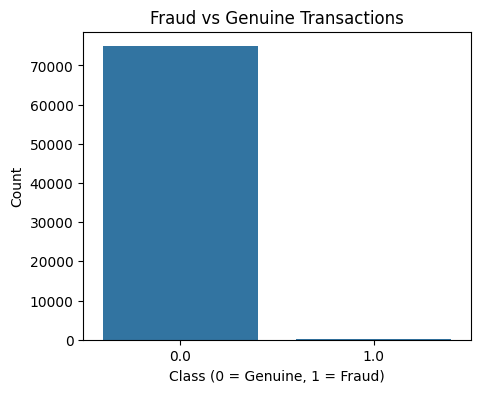

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=data)
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [9]:
print("\nAverage Transaction Amount")

print(data.groupby('Class')['Amount'].mean())



Average Transaction Amount
Class
0.0    97.568058
1.0    95.022350
Name: Amount, dtype: float64


In [10]:
X = data.drop('Class', axis=1)

y = data['Class']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)



Training Data: (60048, 30)
Testing Data : (15012, 30)


In [14]:
nan_indices = y_train[y_train.isna()].index
X_train_cleaned = X_train.drop(nan_indices)
y_train_cleaned = y_train.drop(nan_indices)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_cleaned, y_train_cleaned)

RandomForestClassifier(random_state=42)

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy =", accuracy)


Accuracy = 0.999333866240341



Confusion Matrix
[[14976     1]
 [    9    26]]


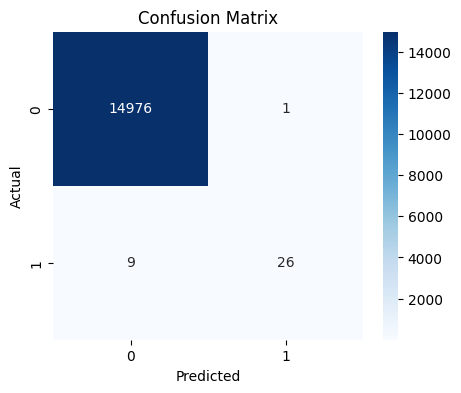

In [17]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")

print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
print("\nClassification Report")

print(classification_report(y_test, y_pred))



Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     14977
         1.0       0.96      0.74      0.84        35

    accuracy                           1.00     15012
   macro avg       0.98      0.87      0.92     15012
weighted avg       1.00      1.00      1.00     15012



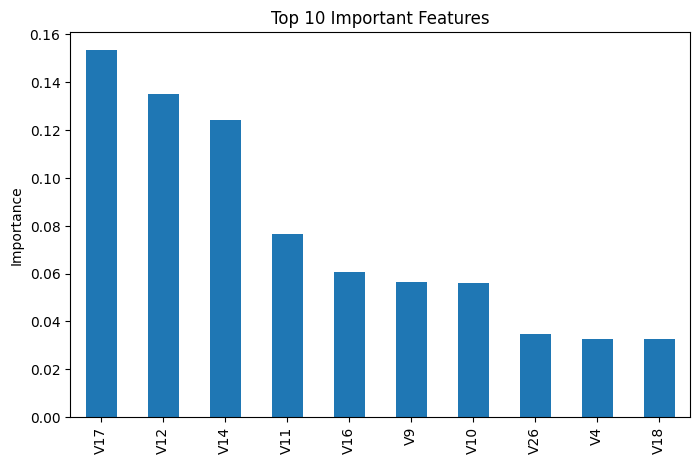


Project Completed Successfully!


In [19]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

print("\nProject Completed Successfully!")